# Handwritten Digit Recognition using CNN

## Objective
Build a Convolutional Neural Network (CNN) to recognize handwritten digits using the MNIST dataset.

# Step 1: Import Libraries

This project uses **TensorFlow**, *NumPy*, and **Matplotlib**.

### Libraries

- TensorFlow
- NumPy
- Matplotlib

```python
import tensorflow as tf
```

In [3]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras import datasets, layers, models

# 2. Loading the Dataset

In [4]:
# Load the MNIST dataset - foundational dataset of 70,000 grayscale images 
# of handwritten digits (0 through 9) 
# used to train and benchmark deep learning models


(x_train, y_train), (x_test, y_test) = datasets.mnist.load_data()

print("Training Images :", x_train.shape)
print("Training Labels :", y_train.shape)

print("Testing Images  :", x_test.shape)
print("Testing Labels  :", y_test.shape)


Training Images : (60000, 28, 28)
Training Labels : (60000,)
Testing Images  : (10000, 28, 28)
Testing Labels  : (10000,)


## 3. Display some sample digit pictures

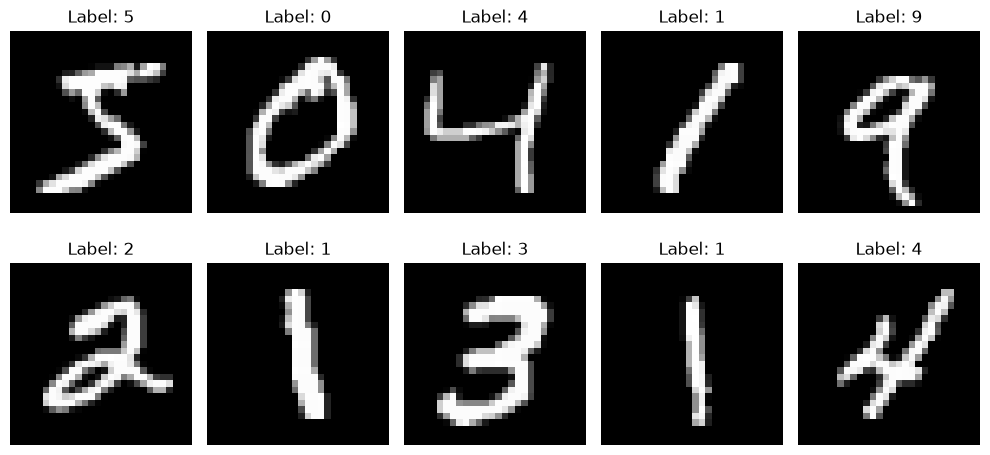

In [5]:
plt.figure(figsize=(10,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i], cmap="gray")
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [6]:
x_train = x_train / 255.0
x_test = x_test / 255.0

print("Maximum Pixel Value :", x_train.max())
print("Minimum Pixel Value :", x_train.min())

Maximum Pixel Value : 1.0
Minimum Pixel Value : 0.0


In [7]:
x_train = x_train.reshape((-1,28,28,1))
x_test = x_test.reshape((-1,28,28,1))

print(x_train.shape)
print(x_test.shape)

(60000, 28, 28, 1)
(10000, 28, 28, 1)


In [8]:
model = tf.keras.Sequential([

    # First Convolution Layer
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),

    # First Pooling Layer
    layers.MaxPooling2D((2,2)),

    # Second Convolution Layer
    layers.Conv2D(64, (3,3), activation='relu'),

    # Second Pooling Layer
    layers.MaxPooling2D((2,2)),

    # Convert 2D feature maps to 1D
    layers.Flatten(),

    # Hidden Layer
    layers.Dense(64, activation='relu'),

    # dropout layer to prevent overfitting
    layers.Dropout(0.5),

    # Output Layer
    layers.Dense(10, activation='softmax')

])

c:\Users\gurle\OneDrive\Desktop\Handwritten_Digit_Recog_Project\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [9]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [10]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
history = model.fit(
    x_train,
    y_train,
    epochs=10,
    validation_data=(x_test, y_test)
)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - accuracy: 0.9158 - loss: 0.2748 - val_accuracy: 0.9812 - val_loss: 0.0598
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.9674 - loss: 0.1135 - val_accuracy: 0.9862 - val_loss: 0.0395
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.9747 - loss: 0.0874 - val_accuracy: 0.9909 - val_loss: 0.0302
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.9799 - loss: 0.0679 - val_accuracy: 0.9881 - val_loss: 0.0361
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.9828 - loss: 0.0584 - val_accuracy: 0.9916 - val_loss: 0.0265
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.9848 - loss: 0.0499 - val_accuracy: 0.9905 - val_loss: 0.0312
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.9864 - loss: 0.0457 - val_accuracy: 0.9919 - val_loss: 0.0273
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.9876 - loss: 0

In [12]:
test_loss, test_accuracy = model.evaluate(x_test, y_test)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9931 - loss: 0.0261
Test Loss: 0.026113159954547882
Test Accuracy: 0.9930999875068665


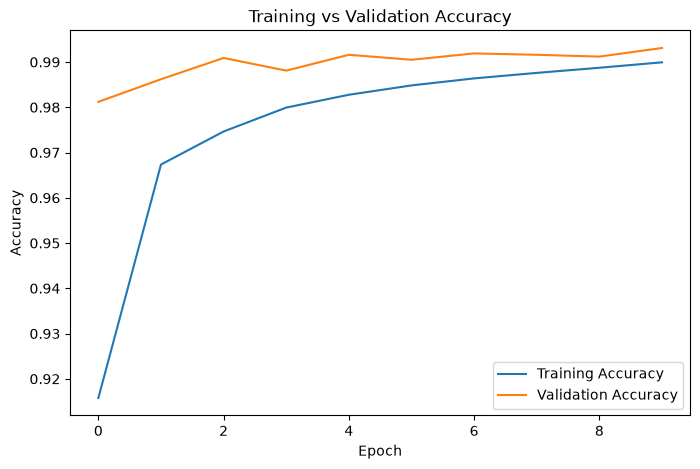

In [13]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()

plt.show()

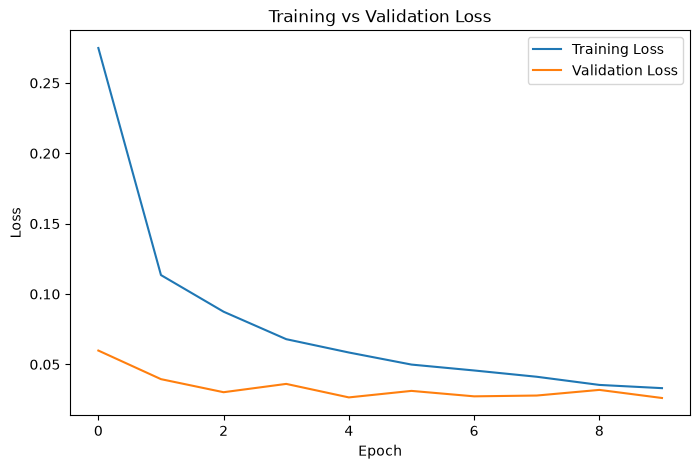

In [14]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Predicted: 7
Actual: 7


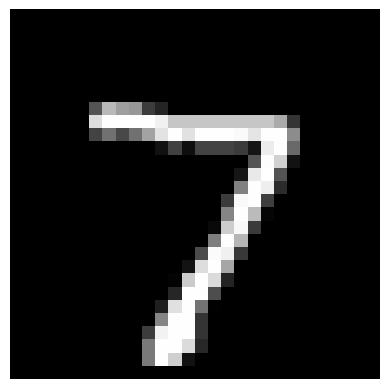

In [15]:
prediction = model.predict(x_test)

predicted_digit = np.argmax(prediction[0])

print("Predicted:", predicted_digit)
print("Actual:", y_test[0])

plt.imshow(x_test[0].reshape(28,28), cmap='gray')
plt.axis("off")
plt.show()

In [16]:
model.save('model/digit_recognizer.keras')

FileNotFoundError: [Errno 2] No such file or directory: 'model/digit_recognizer.keras'